In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix, roc_curve, precision_recall_curve, average_precision_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss, make_scorer
import warnings
warnings.filterwarnings('ignore')

# set display options
sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

               age  daily_screen_time_hours  social_media_hours  gaming_hours  work_study_hours  sleep_hours  \
count  7500.000000              7500.000000         7500.000000   7500.000000       7500.000000  7500.000000   
mean     26.568800                 7.499912            3.273484      2.014183          3.242420     6.737561   
std       5.197108                 2.609188            1.585342      1.146039          1.600765     1.283605   
min      18.000000                 3.000000            0.500000      0.000000          0.500000     4.500000   
25%      22.000000                 5.220000            1.910000      1.020000          1.850000     5.630000   
50%      27.000000                 7.525000            3.270000      2.040000          3.230000     6.720000   
75%      31.000000                 9.810000            4.630000      2.990000          4.640000     7.840000   
max      35.000000                12.000000            6.000000      4.000000          6.000000     9.00

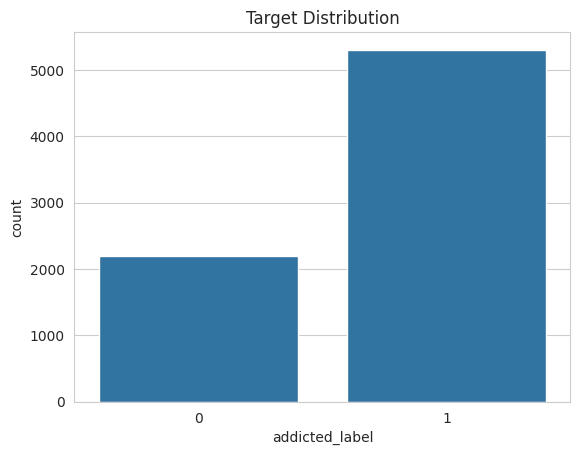

In [40]:
df = pd.read_csv("/kaggle/input/datasets/nalisha/smartphone-usage-and-addiction-analysis-dataset/Smartphone_Usage_And_Addiction_Analysis_7500_Rows (1).csv")

print(df.describe())

print(df["addicted_label"].value_counts(normalize=True))
sns.countplot(x="addicted_label", data=df)
plt.title("Target Distribution")
plt.show()

In [41]:
missing = df.isnull().sum()
print(missing[missing > 0])

print("Duplicates:", df.duplicated().sum())

addiction_level    819
dtype: int64
Duplicates: 0


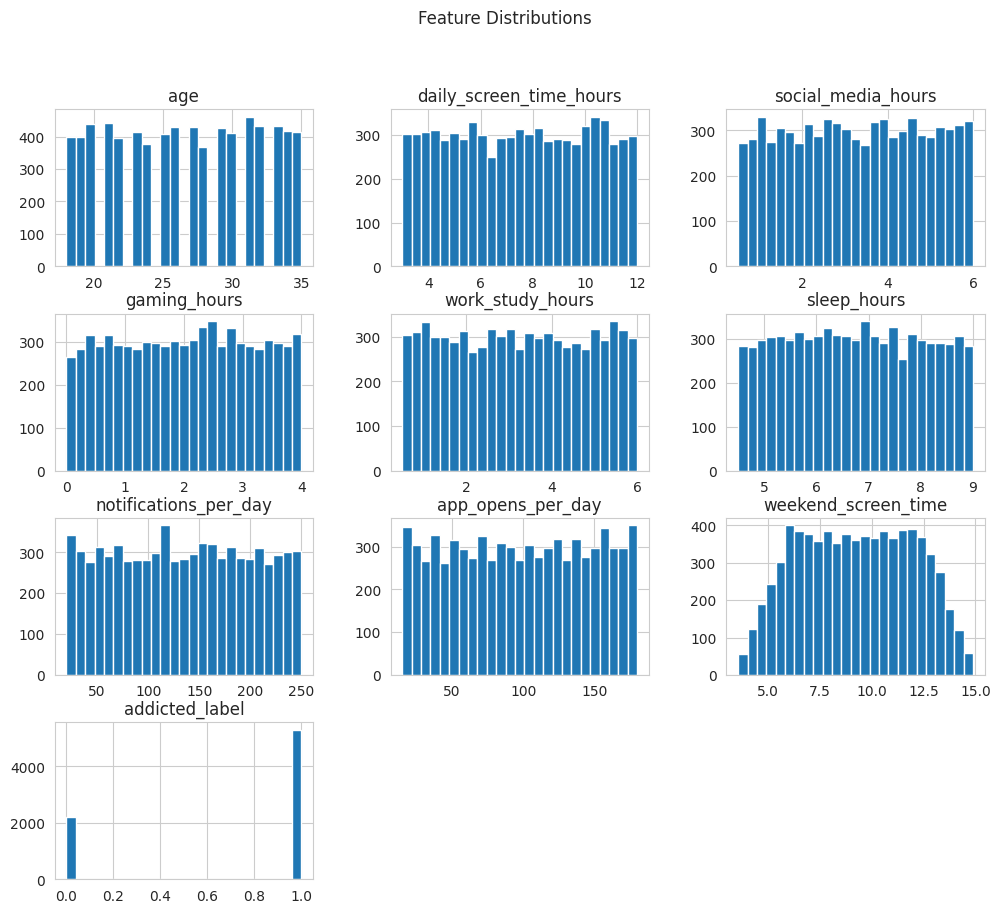

In [42]:
num_cols = df.select_dtypes(include=np.number).columns

df[num_cols].hist(figsize=(12, 10), bins=25)
plt.suptitle("Feature Distributions")
plt.show()

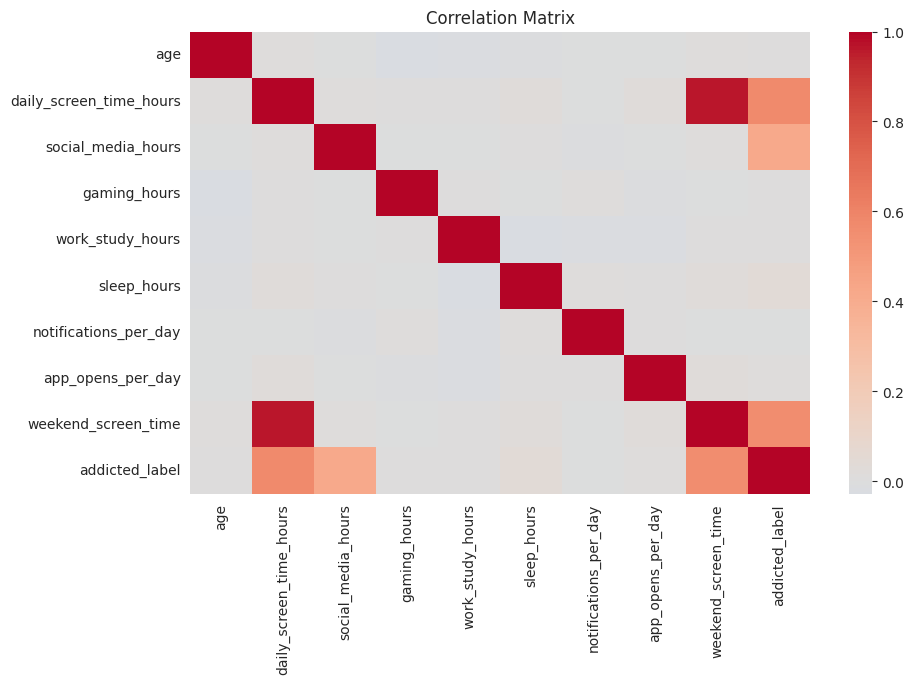

addicted_label             1.000000
daily_screen_time_hours    0.577112
weekend_screen_time        0.555426
social_media_hours         0.414244
sleep_hours                0.035496
app_opens_per_day          0.011041
gaming_hours               0.008485
age                        0.004220
work_study_hours           0.001103
notifications_per_day     -0.000660
Name: addicted_label, dtype: float64


In [43]:
plt.figure(figsize=(10, 6))
sns.heatmap(df[num_cols].corr(), cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

corr = df[num_cols].corr()["addicted_label"].sort_values(ascending=False)
print(corr)

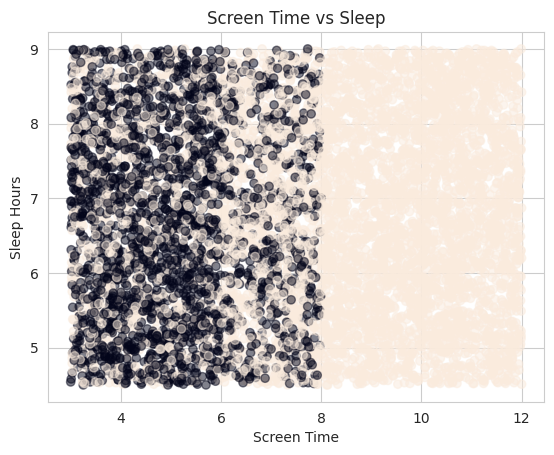

In [44]:
plt.scatter(df["daily_screen_time_hours"], df["sleep_hours"], c=df["addicted_label"], alpha=0.5)
plt.title("Screen Time vs Sleep")
plt.xlabel("Screen Time")
plt.ylabel("Sleep Hours")
plt.show()

In [45]:
df = df.drop(columns=["transaction_id", "user_id"])
print(df.isnull().sum())

age                          0
gender                       0
daily_screen_time_hours      0
social_media_hours           0
gaming_hours                 0
work_study_hours             0
sleep_hours                  0
notifications_per_day        0
app_opens_per_day            0
weekend_screen_time          0
stress_level                 0
academic_work_impact         0
addiction_level            819
addicted_label               0
dtype: int64


In [46]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(col, ":", len(outliers))

age : 0
daily_screen_time_hours : 0
social_media_hours : 0
gaming_hours : 0
work_study_hours : 0
sleep_hours : 0
notifications_per_day : 0
app_opens_per_day : 0
weekend_screen_time : 0
addicted_label : 0


In [47]:
df["stress_level"] = df["stress_level"].map({"Low": 0, "Medium": 1, "High": 2})
df["academic_work_impact"] = df["academic_work_impact"].map({"No": 0, "Yes": 1})

df = pd.get_dummies(df, columns=["gender"], drop_first=True)

In [48]:
df_clean = df.copy()

df_clean["total_screen_time"] = (
    df_clean["daily_screen_time_hours"] + df_clean["weekend_screen_time"]
)

df_clean["digital_intensity"] = (
    df_clean["notifications_per_day"] + df_clean["app_opens_per_day"]
)

df_clean["social_ratio"] = (
    df_clean["social_media_hours"] / (df_clean["daily_screen_time_hours"] + 1e-6)
)

df_clean["sleep_deficit"] = 8 - df_clean["sleep_hours"]

df_clean["entertainment_load"] = (
    df_clean["social_media_hours"] + df_clean["gaming_hours"]
)

In [49]:
df_clean = df_clean.drop(columns=["addiction_level"])

print(df_clean.shape)
print(df_clean.columns)

(7500, 19)
Index(['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'stress_level', 'academic_work_impact',
       'addicted_label', 'gender_Male', 'gender_Other', 'total_screen_time', 'digital_intensity', 'social_ratio',
       'sleep_deficit', 'entertainment_load'],
      dtype='object')


In [50]:
X = df_clean.drop(columns=["addicted_label"])
y = df_clean["addicted_label"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "f1": make_scorer(f1_score),
    "roc_auc": "roc_auc"
}

In [51]:
models = {
    "Logistic Regression": (LogisticRegression(class_weight="balanced", max_iter=1000), True),
    "SVM (RBF)": (SVC(probability=True, class_weight="balanced", random_state=42), True),
    "KNN": (KNeighborsClassifier(), True),
    "Random Forest": (RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42), False),
    "Gradient Boosting": (GradientBoostingClassifier(random_state=42), False),
}

In [52]:
results = []

for name, (model, needs_scaling) in models.items():
    X_data = X_scaled if needs_scaling else X

    scores = cross_validate(model, X_data, y, cv=cv, scoring=scoring)

    results.append({
        "model": name,
        "accuracy": scores["test_accuracy"].mean(),
        "f1": scores["test_f1"].mean(),
        "auc": scores["test_roc_auc"].mean(),
        "auc_std": scores["test_roc_auc"].std()
    })

results_df = pd.DataFrame(results).sort_values("auc", ascending=False)
print(results_df.round(4))

                 model  accuracy      f1     auc  auc_std
3        Random Forest    0.9347  0.9537  0.9891   0.0009
4    Gradient Boosting    0.9357  0.9542  0.9891   0.0006
1            SVM (RBF)    0.9173  0.9396  0.9774   0.0017
0  Logistic Regression    0.9101  0.9345  0.9741   0.0021
2                  KNN    0.8912  0.9241  0.9416   0.0021


In [53]:
# select best model
best_model_name = results_df.iloc[0]["model"]

if best_model_name == "Random Forest":
    best_model = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
    best_model.fit(X, y)

elif best_model_name == "Gradient Boosting":
    best_model = GradientBoostingClassifier(random_state=42)
    best_model.fit(X, y)

elif best_model_name == "SVM (RBF)":
    best_model = SVC(probability=True, class_weight="balanced", random_state=42)
    best_model.fit(X_scaled, y)

else:
    best_model = LogisticRegression(class_weight="balanced", max_iter=1000)
    best_model.fit(X_scaled, y)

daily_screen_time_hours    0.2414
social_media_hours         0.2393
total_screen_time          0.1542
weekend_screen_time        0.1368
entertainment_load         0.0727
social_ratio               0.0623
gaming_hours               0.0184
work_study_hours           0.0115
app_opens_per_day          0.0102
digital_intensity          0.0099
dtype: float64


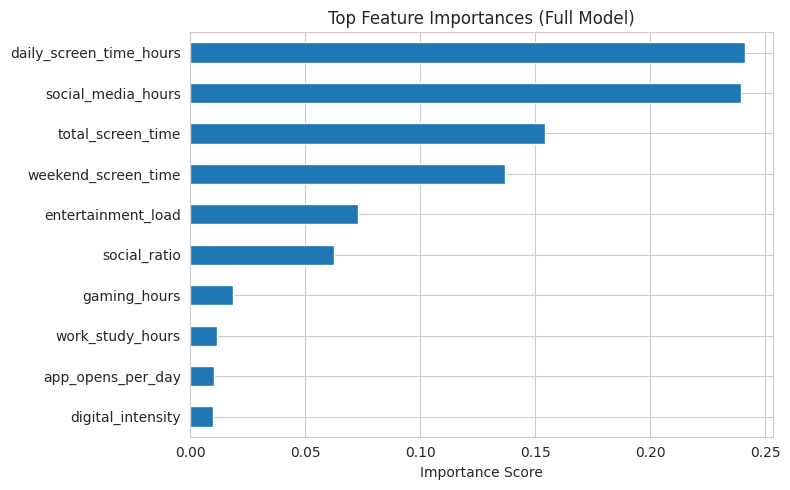

In [54]:
if hasattr(best_model, "feature_importances_"):
    importance = pd.Series(best_model.feature_importances_, index=X.columns)
    importance = importance.sort_values(ascending=False)

    # print top features
    print(importance.head(10).round(4))

    # plot
    plt.figure(figsize=(8, 5))
    importance.head(10).plot(kind="barh")
    plt.gca().invert_yaxis()
    plt.title("Top Feature Importances (Full Model)")
    plt.xlabel("Importance Score")
    plt.tight_layout()
    plt.show()

In [55]:
# extract feature importance from best tree model
importance = pd.Series(best_model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print("Top features:")
print(importance.head(10))

Top features:
daily_screen_time_hours    0.241367
social_media_hours         0.239290
total_screen_time          0.154202
weekend_screen_time        0.136834
entertainment_load         0.072741
social_ratio               0.062309
gaming_hours               0.018379
work_study_hours           0.011469
app_opens_per_day          0.010198
digital_intensity          0.009934
dtype: float64


In [56]:
# keep features that contribute meaningful signal
threshold = 0.05
selected_features = importance[importance > threshold].index.tolist()

print("Selected features:")
print(selected_features)

X_simple = df_clean[selected_features]

Selected features:
['daily_screen_time_hours', 'social_media_hours', 'total_screen_time', 'weekend_screen_time', 'entertainment_load', 'social_ratio']


In [57]:
scaler_simple = StandardScaler()
X_simple_scaled = scaler_simple.fit_transform(X_simple)

In [58]:
simple_results = []

for name, (model, needs_scaling) in models.items():
    X_data = X_simple_scaled if needs_scaling else X_simple

    scores = cross_validate(model, X_data, y, cv=cv, scoring=scoring)

    simple_results.append({
        "model": name,
        "accuracy": scores["test_accuracy"].mean(),
        "f1": scores["test_f1"].mean(),
        "auc": scores["test_roc_auc"].mean(),
        "auc_std": scores["test_roc_auc"].std()
    })

simple_results_df = pd.DataFrame(simple_results).sort_values("auc", ascending=False)
print(simple_results_df.round(4))

                 model  accuracy      f1     auc  auc_std
4    Gradient Boosting    0.9369  0.9548  0.9890   0.0002
3        Random Forest    0.9325  0.9521  0.9885   0.0010
1            SVM (RBF)    0.9248  0.9445  0.9773   0.0021
2                  KNN    0.9204  0.9438  0.9765   0.0021
0  Logistic Regression    0.9103  0.9345  0.9744   0.0019


In [59]:
comparison = pd.DataFrame({
    "model": results_df["model"],
    "full_auc": results_df["auc"].values,
    "simple_auc": simple_results_df["auc"].values,
    "diff": results_df["auc"].values - simple_results_df["auc"].values
})

print(comparison.round(4))

                 model  full_auc  simple_auc    diff
3        Random Forest    0.9891      0.9890  0.0001
4    Gradient Boosting    0.9891      0.9885  0.0006
1            SVM (RBF)    0.9774      0.9773  0.0001
0  Logistic Regression    0.9741      0.9765 -0.0023
2                  KNN    0.9416      0.9744 -0.0328


In [60]:
best_model.fit(X_simple, y)

y_pred = cross_val_predict(best_model, X_simple, y, cv=cv, method="predict")
y_proba = cross_val_predict(best_model, X_simple, y, cv=cv, method="predict_proba")[:, 1]

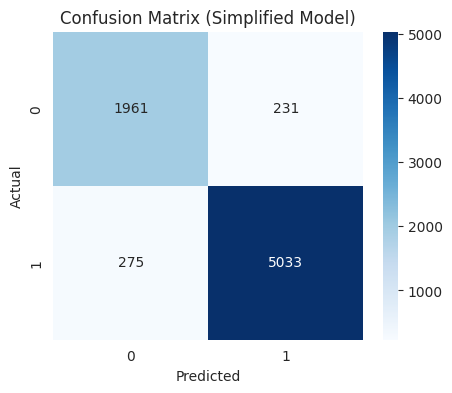

In [61]:
cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Simplified Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

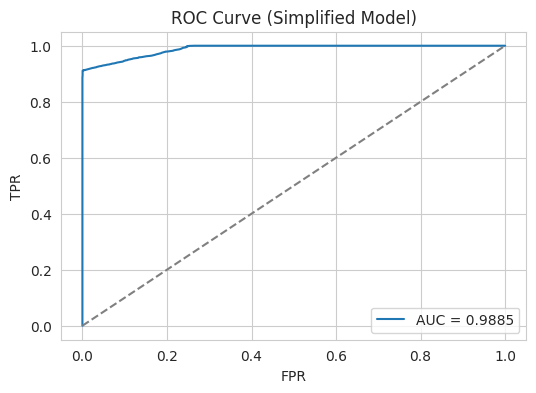

In [62]:
fpr, tpr, _ = roc_curve(y, y_proba)
auc_score = roc_auc_score(y, y_proba)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0,1],[0,1],"--", color="gray")
plt.title("ROC Curve (Simplified Model)")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()

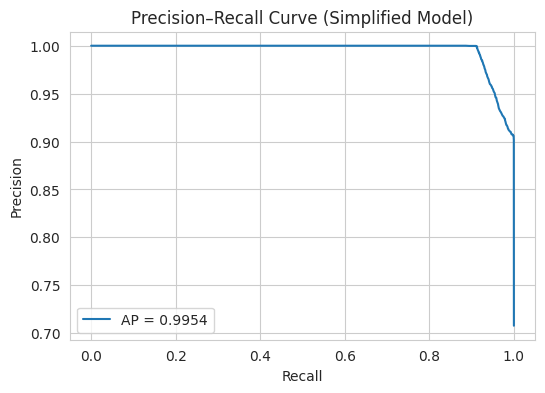

In [63]:
precision, recall, _ = precision_recall_curve(y, y_proba)
avg_precision = average_precision_score(y, y_proba)

plt.figure(figsize=(6,4))
plt.plot(recall, precision, label=f"AP = {avg_precision:.4f}")
plt.title("Precision–Recall Curve (Simplified Model)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

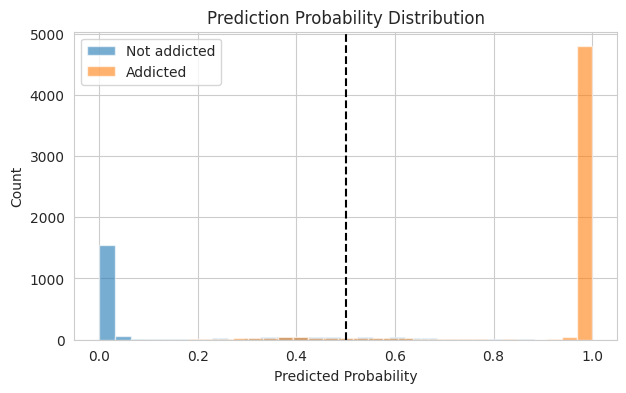

In [64]:
plt.figure(figsize=(7,4))

plt.hist(y_proba[y == 0], bins=30, alpha=0.6, label="Not addicted")
plt.hist(y_proba[y == 1], bins=30, alpha=0.6, label="Addicted")

plt.axvline(0.5, linestyle="--", color="black")

plt.title("Prediction Probability Distribution")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.legend()
plt.show()

In [65]:
acc = accuracy_score(y, y_pred)
f1 = f1_score(y, y_pred)
auc = roc_auc_score(y, y_proba)

print("Final Simplified Model Performance")
print("=" * 40)
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC:      {auc:.4f}")
print(f"Avg Precision: {avg_precision:.4f}")

Final Simplified Model Performance
Accuracy: 0.9325
F1 Score: 0.9521
AUC:      0.9885
Avg Precision: 0.9954
